# Cricket Bat Toe Detection using YOLOv8 and OpenCV - Fixed Version

This notebook is a cleaned version of the original file. It keeps your saved model workflow and fixes common issues:

- Removes exposed Roboflow API key
- Uses reusable path configuration
- Adds dataset/label audit
- Keeps training optional
- Loads saved model correctly
- Uses proper YOLO validation with plots
- Uses `stream=True` for video inference
- Fixes class mapping: `0 = Bat`, `1 = Toe`


In [1]:
# Install dependencies if needed
# Run this cell only once in a new environment.
%pip install ultralytics roboflow opencv-python matplotlib pandas numpy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import os
import shutil

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Fix for some Windows/OpenMP environments
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("✅ Imports completed")


WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ASUS\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports completed


In [3]:
# ==============================
# PROJECT CONFIGURATION
# ==============================

# Dataset folder downloaded from Roboflow
DATASET_DIR = Path("My-First-Project-4")
DATA_YAML = DATASET_DIR / "data.yaml"

# Your trained model path
# Change this only if your run folder name is different.
MODEL_PATH = Path("Cricket_bat_toe_detection/yolov8l_custom2/weights/best.pt")

# Input/output folders
IMAGE_DIR = Path("Image")
OUTPUT_DIR = Path("Output")
SAVED_MODEL_DIR = Path("saved_models")

OUTPUT_DIR.mkdir(exist_ok=True)
SAVED_MODEL_DIR.mkdir(exist_ok=True)

# Class mapping from your dataset
CLASS_NAMES = {
    0: "Bat",
    1: "Toe"
}

# OpenCV colors are BGR format
CLASS_COLORS = {
    0: (255, 0, 0),    # Bat - Blue
    1: (0, 255, 0),    # Toe - Green
}

print("DATA_YAML:", DATA_YAML)
print("MODEL_PATH:", MODEL_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_YAML: My-First-Project-4\data.yaml
MODEL_PATH: Cricket_bat_toe_detection\yolov8l_custom2\weights\best.pt
OUTPUT_DIR: Output


In [4]:
# ==============================
# OPTIONAL: DOWNLOAD DATASET FROM ROBOFLOW
# ==============================
# Do not put your API key directly in this notebook.
# Set your environment variable first:
# Windows PowerShell: setx ROBOFLOW_API_KEY "your_key_here"
# Linux/Mac terminal: export ROBOFLOW_API_KEY="your_key_here"

DOWNLOAD_DATASET = False

if DOWNLOAD_DATASET:
    from roboflow import Roboflow

    api_key = os.getenv("ROBOFLOW_API_KEY")
    if not api_key:
        raise ValueError("ROBOFLOW_API_KEY environment variable not found.")

    rf = Roboflow(api_key=api_key)
    project = rf.workspace("g1-ziqqv").project("my-first-project-1uxd5")
    version = project.version(4)
    dataset = version.download("yolov8")
    print("✅ Dataset downloaded:", dataset.location)
else:
    print("Skipping Roboflow download. Using local dataset folder.")


Skipping Roboflow download. Using local dataset folder.


In [5]:
# ==============================
# BASIC PATH CHECK
# ==============================

required_paths = [DATASET_DIR, DATA_YAML]

for path in required_paths:
    if path.exists():
        print(f"✅ Found: {path}")
    else:
        print(f"❌ Missing: {path}")

if MODEL_PATH.exists():
    print(f"✅ Found saved model: {MODEL_PATH}")
else:
    print(f"⚠️ Saved model not found at: {MODEL_PATH}")
    print("Update MODEL_PATH to your actual best.pt path before inference/validation.")


✅ Found: My-First-Project-4
✅ Found: My-First-Project-4\data.yaml
✅ Found saved model: Cricket_bat_toe_detection\yolov8l_custom2\weights\best.pt


In [6]:
# ==============================
# DATASET LABEL AUDIT
# ==============================
# Checks:
# - missing label files
# - empty label files
# - invalid class IDs
# - invalid YOLO format
# - bounding boxes outside normalized 0-1 range
# - possible segmentation labels mixed into detection dataset

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
VALID_CLASS_IDS = set(CLASS_NAMES.keys())

def audit_yolo_split(split_name: str):
    images_dir = DATASET_DIR / split_name / "images"
    labels_dir = DATASET_DIR / split_name / "labels"

    rows = []

    if not images_dir.exists():
        rows.append({"split": split_name, "issue": "missing_images_dir", "file": str(images_dir), "details": ""})
        return rows

    if not labels_dir.exists():
        rows.append({"split": split_name, "issue": "missing_labels_dir", "file": str(labels_dir), "details": ""})
        return rows

    image_files = [p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        if not label_path.exists():
            rows.append({"split": split_name, "issue": "missing_label", "file": str(img_path), "details": ""})
            continue

        content = label_path.read_text(encoding="utf-8", errors="ignore").strip()
        if not content:
            rows.append({"split": split_name, "issue": "empty_label", "file": str(label_path), "details": ""})
            continue

        for line_no, line in enumerate(content.splitlines(), start=1):
            parts = line.strip().split()

            if len(parts) != 5:
                rows.append({
                    "split": split_name,
                    "issue": "invalid_yolo_format_or_segmentation_label",
                    "file": str(label_path),
                    "details": f"line {line_no}: expected 5 values, got {len(parts)}"
                })
                continue

            try:
                cls_id = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:])
            except ValueError:
                rows.append({
                    "split": split_name,
                    "issue": "non_numeric_label_value",
                    "file": str(label_path),
                    "details": f"line {line_no}: {line}"
                })
                continue

            if cls_id not in VALID_CLASS_IDS:
                rows.append({
                    "split": split_name,
                    "issue": "invalid_class_id",
                    "file": str(label_path),
                    "details": f"line {line_no}: class_id={cls_id}"
                })

            if not all(0 <= v <= 1 for v in [x, y, w, h]):
                rows.append({
                    "split": split_name,
                    "issue": "bbox_value_outside_0_1",
                    "file": str(label_path),
                    "details": f"line {line_no}: x={x}, y={y}, w={w}, h={h}"
                })

            if w <= 0 or h <= 0:
                rows.append({
                    "split": split_name,
                    "issue": "zero_or_negative_bbox_size",
                    "file": str(label_path),
                    "details": f"line {line_no}: w={w}, h={h}"
                })

    # labels without matching images
    label_files = list(labels_dir.glob("*.txt"))
    image_stems = {p.stem for p in image_files}
    for label_path in label_files:
        if label_path.stem not in image_stems:
            rows.append({"split": split_name, "issue": "label_without_image", "file": str(label_path), "details": ""})

    return rows

all_issues = []
for split in ["train", "valid", "test"]:
    all_issues.extend(audit_yolo_split(split))

audit_df = pd.DataFrame(all_issues)

if audit_df.empty:
    print("✅ No obvious label/path issues found.")
else:
    print(f"⚠️ Found {len(audit_df)} dataset issues.")
    display(audit_df.head(50))
    audit_df.to_csv(OUTPUT_DIR / "dataset_audit_issues.csv", index=False)
    print("Saved audit report to:", OUTPUT_DIR / "dataset_audit_issues.csv")


⚠️ Found 16780 dataset issues.


,split,issue,file,details
0,train,empty_label,My-First-Project-4\train\labels\0001.rf.1524d0...,
1,train,empty_label,My-First-Project-4\train\labels\0002_jpg.rf.50...,
2,train,empty_label,My-First-Project-4\train\labels\0004_jpg.rf.f5...,
3,train,empty_label,My-First-Project-4\train\labels\0005_jpg.rf.64...,
4,train,empty_label,My-First-Project-4\train\labels\0006_jpg.rf.ef...,
5,train,empty_label,My-First-Project-4\train\labels\0007_jpg.rf.57...,
6,train,empty_label,My-First-Project-4\train\labels\0009_jpg.rf.9d...,
7,train,empty_label,My-First-Project-4\train\labels\0010_jpg.rf.1a...,
8,train,empty_label,My-First-Project-4\train\labels\0011_jpg.rf.c4...,
9,train,empty_label,My-First-Project-4\train\labels\0012_jpg.rf.71...,


Saved audit report to: Output\dataset_audit_issues.csv


,split,class,count
0,train,Bat,1058
1,train,Toe,1
2,valid,Bat,0
3,valid,Toe,0
4,test,Bat,0
5,test,Toe,0


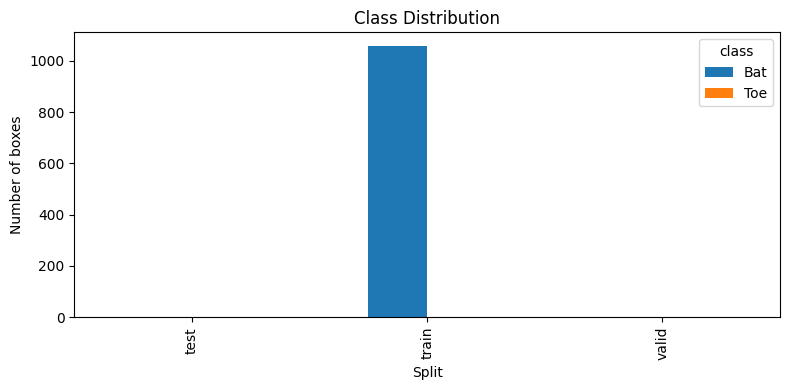

In [7]:
# ==============================
# CLASS DISTRIBUTION CHECK
# ==============================

def class_distribution(split_name: str):
    labels_dir = DATASET_DIR / split_name / "labels"
    counts = {name: 0 for name in CLASS_NAMES.values()}
    total_boxes = 0

    if not labels_dir.exists():
        return counts, total_boxes

    for label_path in labels_dir.glob("*.txt"):
        content = label_path.read_text(encoding="utf-8", errors="ignore").strip()
        if not content:
            continue

        for line in content.splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cls_id = int(float(parts[0]))
            if cls_id in CLASS_NAMES:
                counts[CLASS_NAMES[cls_id]] += 1
                total_boxes += 1

    return counts, total_boxes

dist_rows = []
for split in ["train", "valid", "test"]:
    counts, total = class_distribution(split)
    for class_name, count in counts.items():
        dist_rows.append({"split": split, "class": class_name, "count": count})

dist_df = pd.DataFrame(dist_rows)
display(dist_df)

if not dist_df.empty:
    pivot = dist_df.pivot(index="split", columns="class", values="count").fillna(0)
    pivot.plot(kind="bar", figsize=(8, 4), title="Class Distribution")
    plt.xlabel("Split")
    plt.ylabel("Number of boxes")
    plt.tight_layout()
    plt.show()


In [8]:
# ==============================
# OPTIONAL TRAINING CELL
# ==============================
# You already saved your model, so keep TRAIN_MODEL = False.
# Turn it True only when you want to retrain.

TRAIN_MODEL = False

if TRAIN_MODEL:
    model = YOLO("yolov8s.pt")  # recommended lighter baseline than yolov8l

    results = model.train(
        data=str(DATA_YAML),
        epochs=100,
        imgsz=768,
        batch=8,
        patience=20,
        project="Cricket_bat_toe_detection",
        name="yolov8s_toe_v1",
        device=0  # use 'cpu' if no GPU
    )
else:
    print("Skipping training. Using saved model for validation/inference.")


Skipping training. Using saved model for validation/inference.


In [9]:
# ==============================
# LOAD SAVED MODEL
# ==============================

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Saved model not found: {MODEL_PATH}")

model = YOLO(str(MODEL_PATH))
print("✅ Loaded model:", MODEL_PATH)
print("Model class names:", model.names)


✅ Loaded model: Cricket_bat_toe_detection\yolov8l_custom2\weights\best.pt
Model class names: {0: '0', 1: '1', 2: 'bat', 3: 'toe'}


In [10]:
# ==============================
# VALIDATE SAVED MODEL
# ==============================
# This creates confusion_matrix.png, PR_curve.png, F1_curve.png, etc.

metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=640,
    batch=8,
    conf=0.25,
    plots=True,
    project=str(OUTPUT_DIR),
    name="validation_results"
)

print("✅ Validation completed")
print(metrics)


Ultralytics 8.3.156  Python-3.13.7 torch-2.7.1+cpu CPU (13th Gen Intel Core(TM) i7-13620H)
Model summary (fused): 112 layers, 43,609,692 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 4.61.4 MB/s, size: 40.4 KB)


val: Scanning D:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\My-First-Project-4\valid\labels... 557 images, 0 backgrounds, 0 corrupt: 100%|██████████| 557/557 [00:00<00:00, 837.57it/s]

val: New cache created: D:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\My-First-Project-4\valid\labels.cache
WARNING Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 947. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 70/70 [04:49<00:00,  4.13s/it]


                   all        557        947      0.719      0.701      0.703      0.452
                   bat        557        581      0.962      0.921      0.946      0.732
                   toe        365        366      0.476      0.481      0.459      0.172
Speed: 0.9ms preprocess, 511.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to Output\validation_results
✅ Validation completed
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001BDA8C60D70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.0

In [ ]:
# ==============================
# IMAGE PREDICTION
# ==============================
# Change image name according to your test image.

IMAGE_PATH = IMAGE_DIR / "Image\3.mp4"

if IMAGE_PATH.exists():
    results = model.predict(
        source=str(IMAGE_PATH),
        save=True,
        conf=0.25,
        iou=0.45,
        project=str(OUTPUT_DIR),
        name="image_predictions"
    )
    print("✅ Image prediction completed")
else:
    print(f"⚠️ Image not found: {IMAGE_PATH}")
    print("Update IMAGE_PATH before running this cell.")


⚠️ Image not found: Image\Image.mp4
Update IMAGE_PATH before running this cell.


In [12]:
# ==============================
# VIDEO PREDICTION - YOLO BUILT-IN SAVE
# ==============================
# stream=True prevents memory issues on long videos.

VIDEO_PATH = IMAGE_DIR / "3.mp4"

if VIDEO_PATH.exists():
    results = model.predict(
        source=str(VIDEO_PATH),
        save=True,
        save_txt=False,
        conf=0.25,
        iou=0.45,
        show=False,
        stream=True,
        project=str(OUTPUT_DIR),
        name="video_predictions"
    )

    for _ in results:
        pass

    print("✅ Video prediction completed")
else:
    print(f"⚠️ Video not found: {VIDEO_PATH}")
    print("Update VIDEO_PATH before running this cell.")



video 1/1 (frame 1/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\Image\3.mp4: 384x640 1 bat, 286.2ms
video 1/1 (frame 2/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\Image\3.mp4: 384x640 1 bat, 270.2ms
video 1/1 (frame 3/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\Image\3.mp4: 384x640 2 bats, 2 toes, 285.0ms
video 1/1 (frame 4/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\Image\3.mp4: 384x640 2 bats, 1 toe, 275.1ms
video 1/1 (frame 5/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\Image\3.mp4: 384x640 2 bats, 2 toes, 315.8ms
video 1/1 (frame 6/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\Image\3.mp4: 384x640 2 bats, 1 toe, 284.0ms
video 1/1 (frame 7/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and toe detection\Image\3.mp4: 384x640 2 bats, 1 toe, 270.9ms
video 1/1 (frame 8/42) d:\programs\Linkites\zip_&_Files\adi\Cricket bat and

In [16]:
# ==============================
# VIDEO FRAME EXPORT WITH CUSTOM COLORS
# ==============================
# Saves annotated frames as images. Use this only when you need frame-wise output.

VIDEO_PATH = IMAGE_DIR / "3.mp4"
FRAME_OUTPUT_DIR = OUTPUT_DIR / "annotated_frames"
FRAME_OUTPUT_DIR.mkdir(exist_ok=True)

if VIDEO_PATH.exists():
    cap = cv2.VideoCapture(str(VIDEO_PATH))

    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {VIDEO_PATH}")

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        result = model(frame, conf=0.25, iou=0.45, verbose=False)[0]

        for box in result.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            label = f"{model.names.get(cls_id, cls_id)} {conf:.2f}"
            color = CLASS_COLORS.get(cls_id, (255, 255, 255))

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(
                frame,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

        out_path = FRAME_OUTPUT_DIR / f"frame_{frame_count:04d}.jpg"
        cv2.imwrite(str(out_path), frame)
        frame_count += 1

    cap.release()
    print(f"✅ Detection complete. {frame_count} frames saved in: {FRAME_OUTPUT_DIR}")
else:
    print(f"⚠️ Video not found: {VIDEO_PATH}")


✅ Detection complete. 42 frames saved in: Output\annotated_frames


In [14]:
# ==============================
# SAVE/COPY FINAL MODEL
# ==============================

FINAL_MODEL_PATH = SAVED_MODEL_DIR / "cricket_bat_toe_best.pt"

if MODEL_PATH.exists():
    shutil.copy(str(MODEL_PATH), str(FINAL_MODEL_PATH))
    print(f"✅ Model copied to: {FINAL_MODEL_PATH}")
else:
    print(f"❌ Model not found: {MODEL_PATH}")


✅ Model copied to: saved_models\cricket_bat_toe_best.pt
